# OSM Malakal (road network)

Personal notes: `eda/talk/N_osm.md`.

**Why Malakal:** town in Upper Nile, in the stakeholder case, has OSM coverage. Not a national road map.

**Why roads:** later, Petricola-style access (can people reach clinics if roads flood). Not for counting flood pixels of South Sudan.

First run needs internet. After that, shapefiles in `raw_data/OSM/Malakal, South Sudan/`.


In [1]:
from pathlib import Path
import osmnx as ox
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

%matplotlib inline

ROOT = Path(".").resolve()
if not (ROOT / "raw_data").exists():
    ROOT = Path("..").resolve()
DATA = ROOT / "raw_data"
OUT = ROOT / "eda" / "outputs" / "osm"
OUT.mkdir(parents=True, exist_ok=True)

PLACE = "Malakal, South Sudan"
save_dir = DATA / "OSM" / PLACE
save_dir.mkdir(parents=True, exist_ok=True)


In [2]:
# reuse shapefiles if we already downloaded (needs internet only the first time)
# download if edges not present
edges_path = save_dir / "edges.shp"
nodes_path = save_dir / "nodes.shp"
if edges_path.exists() and nodes_path.exists():
    print("loading saved shapefiles")
    nodes = gpd.read_file(nodes_path)
    edges = gpd.read_file(edges_path)
    G = ox.graph_from_gdfs(nodes.set_index("osmid"), edges.set_index(["u", "v", "key"]))
else:
    print("downloading from OSM...")
    G = ox.graph_from_place(PLACE, network_type="drive")
    nodes, edges = ox.graph_to_gdfs(G)
    nodes.to_file(nodes_path)
    edges.to_file(edges_path)
    print("saved to", save_dir)

print("nodes", len(nodes), "edges", len(edges))
stats = {
    "place": PLACE,
    "n_nodes": len(nodes),
    "n_edges": len(edges),
    "crs": str(edges.crs),
}
pd.DataFrame([stats]).to_csv(OUT / "malakal_network_stats.csv", index=False)
stats


downloading from OSM...


saved to /home/plugga404/Documents/VS_files/university/Y3/Q1/Capstone/group_repo/raw_data/OSM/Malakal, South Sudan
nodes 708 edges 2255


/tmp/ipykernel_83110/2794916694.py:13: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  nodes.to_file(nodes_path)
/usr/lib/python3.14/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'street_count' to 'street_cou'
  ogr_write(


{'place': 'Malakal, South Sudan',
 'n_nodes': 708,
 'n_edges': 2255,
 'crs': 'epsg:4326'}

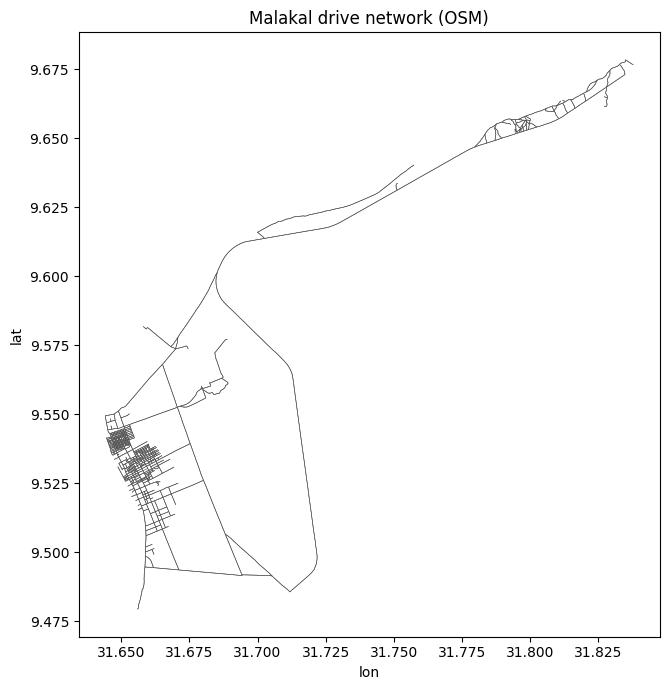

In [3]:
# nodes/edges already in memory from the cell above
fig, ax = plt.subplots(figsize=(7, 7))
edges.plot(ax=ax, linewidth=0.4, color="0.3")
ax.set_title("Malakal drive network (OSM)")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
fig.tight_layout()
fig.savefig(OUT / "01_malakal_roads.png", dpi=150)
plt.show()


Unusual flood points near Malakal bbox (quick overlay).

{'lon_min': np.float64(31.5940817), 'lon_max': np.float64(31.8880215), 'lat_min': np.float64(9.429362999999999), 'lat_max': np.float64(9.7283626)}
unusual unique px near Malakal 2023 1658


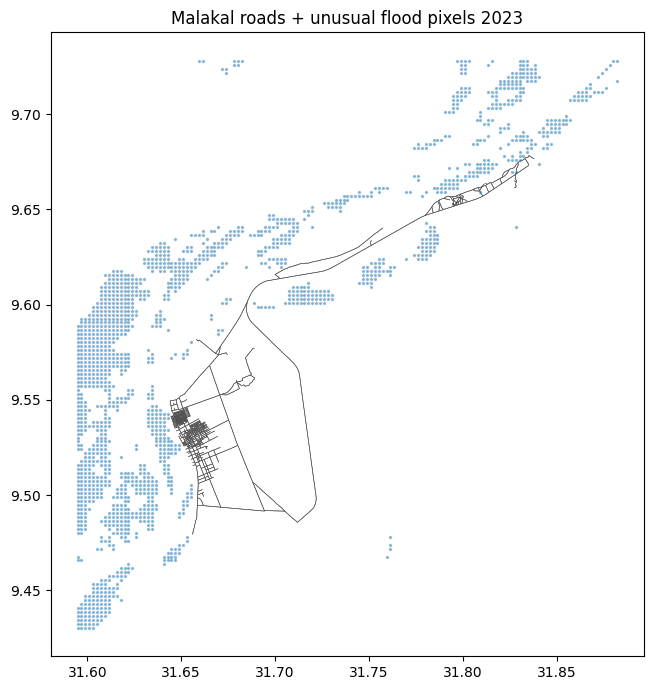

In [4]:
# pad the city bbox a bit so nearby unusual water still shows
minx, miny, maxx, maxy = edges.total_bounds
pad = 0.05
bbox = dict(lon_min=minx - pad, lon_max=maxx + pad, lat_min=miny - pad, lat_max=maxy + pad)
print(bbox)

parts = []
for tile in ["h20v08", "h21v08"]:
    path = DATA / "flood_masks" / "compact_unusual" / f"flood_events_{tile}_2023.parquet"
    df = pd.read_parquet(path, columns=["lat", "lon"])
    parts.append(df)
u = pd.concat(parts, ignore_index=True)
m = (
    (u.lat >= bbox["lat_min"]) & (u.lat <= bbox["lat_max"]) &
    (u.lon >= bbox["lon_min"]) & (u.lon <= bbox["lon_max"])
)
u = u.loc[m].drop_duplicates()
print("unusual unique px near Malakal 2023", len(u))

fig, ax = plt.subplots(figsize=(7, 7))
edges.plot(ax=ax, linewidth=0.4, color="0.3", zorder=1)
if len(u):
    ax.scatter(u.lon, u.lat, s=2, c="C0", alpha=0.4, zorder=2)
ax.set_title("Malakal roads + unusual flood pixels 2023")
fig.tight_layout()
fig.savefig(OUT / "02_malakal_roads_floods.png", dpi=150)
plt.show()
